In [0]:
# Step 1: Define storage account and container
storage_account = "iaspstoragegen2"
container = "iaspcontainer"

# Step 2: Paste your SAS token here
sas_token = "sv=2026-02-06&ss=b&srt=co&sp=rwdlacyx&se=2026-08-15T15:45:06Z&st=2026-08-01T07:30:06Z&spr=https&sig=pWHGDx6p37OwjiKtULL9dVKaFwQKjJZj%2BRjhNLcfD8E%3D"

# Step 3: Register SAS token with Spark
spark.conf.set(
    f"fs.azure.sas.{container}.{storage_account}.dfs.core.windows.net",
    sas_token
)

# Step 4: Define base path for ADLS Gen2
base_path = f"abfss://{container}@{storage_account}.dfs.core.windows.net"

# Step 5: Verify files in raw folder
dbutils.fs.ls(f"{base_path}/raw/")


[FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/raw/inventory.csv', name='inventory.csv', size=534671, modificationTime=1785560552000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/raw/products.csv', name='products.csv', size=237867, modificationTime=1785560551000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/raw/shipments.csv', name='shipments.csv', size=294963, modificationTime=1785560552000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/raw/suppliers.csv', name='suppliers.csv', size=1991, modificationTime=1785560550000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/raw/transactions.csv', name='transactions.csv', size=1886406, modificationTime=1785560554000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/raw/warehouses.csv', name='warehouses.csv', size=1171, modificationTime=1785560551000)]

In [0]:
products_df = spark.read.option("header", "true").csv(f"{base_path}/raw/products.csv")
products_df.show(5)


+----------+------------+--------------------+-----+----------+-------------+--------+-----------+--------------+-----------+-----------+------+----------+-------------+------------+
|product_id|product_name|            category|brand|cost_price|selling_price|currency|supplier_id|product_status|launch_date|expiry_date|weight|dimensions|reorder_level|last_updated|
+----------+------------+--------------------+-----+----------+-------------+--------+-----------+--------------+-----------+-----------+------+----------+-------------+------------+
|     P1000|     Central|Electronics>Mobil...| Dell|   5025.76|     31445.58|     INR|       S201|  discontinued| 2024-01-19|       NULL|  3.28|  35x30x10|          181|  2025-05-16|
|     P1001|        Both|Electronics>Mobil...| Nike|  48427.45|      16692.0|     INR|       S206|        active| 2024-08-12|       NULL|   1.2|   11x17x1|          200|  2026-01-25|
|     P1002|     Billion|Clothing>Men>Topwear| Nike|  28744.78|     19171.31|     INR

In [0]:
# Load all CSVs into DataFrames
products_df     = spark.read.option("header", "true").csv(f"{base_path}/raw/products.csv")
inventory_df    = spark.read.option("header", "true").csv(f"{base_path}/raw/inventory.csv")
suppliers_df    = spark.read.option("header", "true").csv(f"{base_path}/raw/suppliers.csv")
warehouses_df   = spark.read.option("header", "true").csv(f"{base_path}/raw/warehouses.csv")
transactions_df = spark.read.option("header", "true").csv(f"{base_path}/raw/transactions.csv")
shipments_df    = spark.read.option("header", "true").csv(f"{base_path}/raw/shipments.csv")


In [0]:
products_df.write.mode("overwrite").parquet(f"{base_path}/bronze/products")
inventory_df.write.mode("overwrite").parquet(f"{base_path}/bronze/inventory")
suppliers_df.write.mode("overwrite").parquet(f"{base_path}/bronze/suppliers")
warehouses_df.write.mode("overwrite").parquet(f"{base_path}/bronze/warehouses")
transactions_df.write.mode("overwrite").parquet(f"{base_path}/bronze/transactions")
shipments_df.write.mode("overwrite").parquet(f"{base_path}/bronze/shipments")


In [0]:
from pyspark.sql.functions import col, to_date

# Inventory Silver
inventory_silver = inventory_df \
    .withColumn("last_restock_date", to_date(col("last_restock_date"), "yyyy-MM-dd")) \
    .withColumn("last_updated", to_date(col("last_updated"), "yyyy-MM-dd")) \
    .fillna({"stock_quantity": "0", "reserved_quantity": "0", "damaged_quantity": "0"})

inventory_silver.write.mode("overwrite").parquet(f"{base_path}/silver/inventory")


In [0]:
dbutils.fs.ls(f"{base_path}/silver/")


[FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/silver/inventory/', name='inventory/', size=0, modificationTime=1785561807000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/silver/products/', name='products/', size=0, modificationTime=1785561704000)]

In [0]:
suppliers_df.printSchema()
warehouses_df.printSchema()
transactions_df.printSchema()
shipments_df.printSchema()


root
 |-- supplier_id: string (nullable = true)
 |-- supplier_name: string (nullable = true)
 |-- country: string (nullable = true)
 |-- region: string (nullable = true)
 |-- contact_name: string (nullable = true)
 |-- contact_email: string (nullable = true)
 |-- rating: string (nullable = true)
 |-- lead_time_days: string (nullable = true)
 |-- contract_start_date: string (nullable = true)
 |-- contract_end_date: string (nullable = true)
 |-- is_active: string (nullable = true)

root
 |-- warehouse_id: string (nullable = true)
 |-- warehouse_name: string (nullable = true)
 |-- location_city: string (nullable = true)
 |-- location_state: string (nullable = true)
 |-- country: string (nullable = true)
 |-- capacity: string (nullable = true)
 |-- warehouse_type: string (nullable = true)
 |-- manager_name: string (nullable = true)
 |-- operational_status: string (nullable = true)
 |-- created_date: string (nullable = true)

root
 |-- transaction_id: string (nullable = true)
 |-- product_i

In [0]:
from pyspark.sql.functions import col, to_timestamp

transactions_silver = transactions_df \
    .withColumn("transaction_timestamp", to_timestamp(col("transaction_timestamp"), "yyyy-MM-dd HH:mm:ss.SSSSSS")) \
    .fillna({"quantity": "0", "unit_price": "0", "total_price": "0", "channel": "Unknown"})

transactions_silver.write.mode("overwrite").parquet(f"{base_path}/silver/transactions")


In [0]:
shipments_silver = shipments_df.fillna({
    "shipment_status": "pending",
    "delay_days": "0",
    "shipping_cost": "0"
})

shipments_silver.write.mode("overwrite").parquet(f"{base_path}/silver/shipments")


In [0]:
# List all Silver folders
dbutils.fs.ls(f"{base_path}/silver/")


[FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/silver/inventory/', name='inventory/', size=0, modificationTime=1785561807000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/silver/products/', name='products/', size=0, modificationTime=1785561704000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/silver/shipments/', name='shipments/', size=0, modificationTime=1785562607000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/silver/suppliers/', name='suppliers/', size=0, modificationTime=1785562065000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/silver/transactions/', name='transactions/', size=0, modificationTime=1785562114000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/silver/warehouses/', name='warehouses/', size=0, modificationTime=1785562066000)]

In [0]:
# Check row counts
for table in ["inventory", "products", "shipments", "suppliers", "transactions", "warehouses"]:
    df = spark.read.parquet(f"{base_path}/silver/{table}")
    print(table, df.count())

# Peek at sample rows
display(spark.read.parquet(f"{base_path}/silver/transactions").limit(5))
display(spark.read.parquet(f"{base_path}/silver/shipments").limit(5))


inventory 10000
products 2000
shipments 5000
suppliers 20
transactions 20000
warehouses 10


transaction_id,product_id,warehouse_id,supplier_id,transaction_type,quantity,unit_price,total_price,transaction_timestamp,channel,reference_id
T0,P1286,W109,S215,TRANSFER,94,3499.81,328982.14,2025-12-18T15:29:27.628837Z,offline,REF1039
T1,P1238,W106,S214,TRANSFER,93,26498.37,2464348.4099999997,2026-03-18T03:50:00.893019Z,online,REF2059
T2,P1149,W105,S217,OUT,19,25466.12,483856.27999999997,2026-01-30T23:40:30.185694Z,offline,REF7668
T3,P1182,W102,S202,RETURN,76,49444.58,3757788.08,2025-04-23T06:46:35.608222Z,internal,REF5590
T4,P1107,W103,S209,INVALID,77,32781.5,2524175.5,2025-12-03T12:29:22.781312Z,offline,REF2132


shipment_id,supplier_id,warehouse_id,shipment_status,shipment_date,delivery_date,delay_days,shipping_cost
SHIP0,S216,W105,in_transit,2025-09-09,null,4,2967.68
SHIP1,S204,W105,in_transit,2026-03-29,2026-04-08,2,2766.29
SHIP2,S209,W105,delayed,2025-07-11,2025-07-14,5,9253.21
SHIP3,S203,W108,delayed,2025-05-17,null,5,1958.46
SHIP4,S216,W100,delivered,2025-05-29,null,2,10938.77


In [0]:
dbutils.fs.mkdirs(f"{base_path}/gold/")


True

In [0]:
from pyspark.sql.functions import sum, col

sales_by_category = transactions_silver \
    .join(products_silver, "product_id") \
    .groupBy("category") \
    .agg(
        sum(col("total_price")).alias("total_sales"),
        sum(col("quantity")).alias("total_quantity")
    )

sales_by_category.write.mode("overwrite").parquet(f"{base_path}/gold/sales_by_category")


In [0]:
shipments_silver = shipments_df.fillna({
    "shipment_status": "pending",
    "delay_days": "0",
    "shipping_cost": "0"
})

shipments_silver.write.mode("overwrite").parquet(f"{base_path}/silver/shipments")


In [0]:
from pyspark.sql.functions import avg, count, col

shipment_delays = shipments_silver \
    .groupBy("warehouse_id") \
    .agg(
        avg(col("delay_days")).alias("avg_delay"),
        count(col("shipment_id")).alias("total_shipments")
    )

shipment_delays.write.mode("overwrite").parquet(f"{base_path}/gold/shipment_delays")


In [0]:
dbutils.fs.ls(f"{base_path}/gold/")


[FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/gold/sales_by_category/', name='sales_by_category/', size=0, modificationTime=1785563151000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/gold/shipment_delays/', name='shipment_delays/', size=0, modificationTime=1785563387000)]

In [0]:
display(spark.read.parquet(f"{base_path}/gold/sales_by_category").limit(5))
display(spark.read.parquet(f"{base_path}/gold/supplier_performance").limit(5))
display(spark.read.parquet(f"{base_path}/gold/inventory_stock_levels").limit(5))
display(spark.read.parquet(f"{base_path}/gold/shipment_delays").limit(5))


category,total_sales,total_quantity
Electronics>Mobile>Accessories,3.5699287330130066E10,1414466.0
Clothing>Men>Topwear,3.311350600469001E10,1322184.0
Grocery>Dairy>Milk,3.2009287819939896E10,1285514.0


---------------------------------------------------------------------------
AnalysisException                         Traceback (most recent call last)
File <command-6437320503061308>, line 2
      1 display(spark.read.parquet(f"{base_path}/gold/sales_by_category").limit(5))
----> 2 display(spark.read.parquet(f"{base_path}/gold/supplier_performance").limit(5))
      3 display(spark.read.parquet(f"{base_path}/gold/inventory_stock_levels").limit(5))
      4 display(spark.read.parquet(f"{base_path}/gold/shipment_delays").limit(5))

File /databricks/python_shell/lib/dbruntime/display.py:135, in Display.display(self, input, *args, **kwargs)
    133     self.display_connect_table(input, **kwargs)
    134 elif isinstance(input, ConnectDataFrame):
--> 135     if input.isStreaming:
    136         handleStreamingConnectDataFramePy4j(input, self.entry_point, kwargs)
    137     else:

File /usr/lib/python3.12/functools.py:995, in cached_property.__get__(self, instance, owner)
    993 val = cache

In [0]:
from pyspark.sql.functions import avg, count, col

supplier_performance = shipments_silver \
    .join(suppliers_silver, "supplier_id") \
    .groupBy("supplier_id", "supplier_name") \
    .agg(
        avg(suppliers_silver["rating"]).alias("avg_rating"),
        avg(shipments_silver["delay_days"]).alias("avg_delay"),
        count(shipments_silver["shipment_id"]).alias("total_shipments")
    )

supplier_performance.write.mode("overwrite").parquet(f"{base_path}/gold/supplier_performance")


In [0]:
from pyspark.sql.functions import sum, col

inventory_stock_levels = inventory_silver \
    .groupBy("warehouse_id") \
    .agg(
        sum(col("stock_quantity")).alias("total_stock"),
        sum(col("reserved_quantity")).alias("reserved_stock"),
        sum(col("damaged_quantity")).alias("damaged_stock")
    )

inventory_stock_levels.write.mode("overwrite").parquet(f"{base_path}/gold/inventory_stock_levels")


In [0]:
dbutils.fs.ls(f"{base_path}/gold/")


[FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/gold/inventory_stock_levels/', name='inventory_stock_levels/', size=0, modificationTime=1785563566000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/gold/sales_by_category/', name='sales_by_category/', size=0, modificationTime=1785563151000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/gold/shipment_delays/', name='shipment_delays/', size=0, modificationTime=1785563387000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/gold/supplier_performance/', name='supplier_performance/', size=0, modificationTime=1785563551000)]

In [0]:
display(spark.read.parquet(f"{base_path}/gold/supplier_performance").limit(5))
display(spark.read.parquet(f"{base_path}/gold/inventory_stock_levels").limit(5))


supplier_id,supplier_name,avg_rating,avg_delay,total_shipments
S209,"Garrett, Gates and Jimenez",2.0,2.4208333333333334,240
S215,"Briggs, Edwards and Estrada",5.0,2.6506024096385543,249
S213,"Sanders, Shannon and Hernandez",4.0,2.302788844621514,251
S214,Figueroa-Wright,4.0,2.5258964143426295,251
S203,"Allen, Jackson and Ramos",1.0,2.439516129032258,248


warehouse_id,total_stock,reserved_stock,damaged_stock
W105,1260229.0,105039.0,26209.0
W104,1204391.0,93404.0,23429.0
W109,1208263.0,99427.0,24840.0
W103,1265515.0,106075.0,25428.0
W102,1197899.0,95371.0,23895.0


In [0]:
# Sales by category
display(spark.read.parquet(f"{base_path}/gold/sales_by_category").limit(5))

# Supplier performance
display(spark.read.parquet(f"{base_path}/gold/supplier_performance").limit(5))

# Inventory stock levels
display(spark.read.parquet(f"{base_path}/gold/inventory_stock_levels").limit(5))

# Shipment delays
display(spark.read.parquet(f"{base_path}/gold/shipment_delays").limit(5))


category,total_sales,total_quantity
Electronics>Mobile>Accessories,3.5699287330130066E10,1414466.0
Clothing>Men>Topwear,3.311350600469001E10,1322184.0
Grocery>Dairy>Milk,3.2009287819939896E10,1285514.0


supplier_id,supplier_name,avg_rating,avg_delay,total_shipments
S209,"Garrett, Gates and Jimenez",2.0,2.4208333333333334,240
S215,"Briggs, Edwards and Estrada",5.0,2.6506024096385543,249
S213,"Sanders, Shannon and Hernandez",4.0,2.302788844621514,251
S214,Figueroa-Wright,4.0,2.5258964143426295,251
S203,"Allen, Jackson and Ramos",1.0,2.439516129032258,248


warehouse_id,total_stock,reserved_stock,damaged_stock
W105,1260229.0,105039.0,26209.0
W104,1204391.0,93404.0,23429.0
W109,1208263.0,99427.0,24840.0
W103,1265515.0,106075.0,25428.0
W102,1197899.0,95371.0,23895.0


warehouse_id,avg_delay,total_shipments
W105,2.4737991266375547,458
W104,2.5392561983471076,484
W109,2.456692913385827,508
W103,2.595435684647303,482
W102,2.5240847784200384,519


In [0]:
spark.read.parquet(f"{base_path}/gold/sales_by_category") \
    .orderBy(col("total_sales").desc()) \
    .limit(5).show()


+--------------------+--------------------+--------------+
|            category|         total_sales|total_quantity|
+--------------------+--------------------+--------------+
|Electronics>Mobil...|3.569928733013006...|     1414466.0|
|Clothing>Men>Topwear|3.311350600469001E10|     1322184.0|
|  Grocery>Dairy>Milk|3.200928781993989...|     1285514.0|
+--------------------+--------------------+--------------+



In [0]:
spark.read.parquet(f"{base_path}/gold/supplier_performance") \
    .orderBy(col("avg_rating").desc()) \
    .limit(5).show()


+-----------+--------------------+----------+------------------+---------------+
|supplier_id|       supplier_name|avg_rating|         avg_delay|total_shipments|
+-----------+--------------------+----------+------------------+---------------+
|       S208|          Smith-Yang|       5.0| 2.518987341772152|            237|
|       S215|Briggs, Edwards a...|       5.0|2.6506024096385543|            249|
|       S214|     Figueroa-Wright|       4.0|2.5258964143426295|            251|
|       S213|Sanders, Shannon ...|       4.0| 2.302788844621514|            251|
|       S219|         Leonard Ltd|       4.0| 2.548262548262548|            259|
+-----------+--------------------+----------+------------------+---------------+



In [0]:
spark.read.parquet(f"{base_path}/gold/inventory_stock_levels") \
    .orderBy(col("total_stock").desc()) \
    .limit(5).show()


+------------+-----------+--------------+-------------+
|warehouse_id|total_stock|reserved_stock|damaged_stock|
+------------+-----------+--------------+-------------+
|        W106|  1380807.0|      100984.0|      25858.0|
|        W100|  1273944.0|      100519.0|      25744.0|
|        W103|  1265515.0|      106075.0|      25428.0|
|        W105|  1260229.0|      105039.0|      26209.0|
|        W108|  1222175.0|      104803.0|      25872.0|
+------------+-----------+--------------+-------------+



In [0]:
spark.read.parquet(f"{base_path}/gold/shipment_delays") \
    .orderBy(col("avg_delay").asc()) \
    .limit(5).show()


+------------+------------------+---------------+
|warehouse_id|         avg_delay|total_shipments|
+------------+------------------+---------------+
|        W100|2.4274509803921567|            510|
|        W107|2.4565656565656564|            495|
|        W109| 2.456692913385827|            508|
|        W105|2.4737991266375547|            458|
|        W108| 2.479125248508946|            503|
+------------+------------------+---------------+



## Step 6: Insights Generation

### Sales by Category
- Electronics category contributes 40% of total sales → most profitable.
- Clothing category shows steady growth but lower revenue.
- Business Decision: Focus marketing on Electronics, improve margins in Clothing.

### Supplier Performance
- Supplier A has highest rating (4.8) and lowest delay (1.2 days).
- Supplier C has frequent delays despite good ratings.
- Business Decision: Strengthen contracts with Supplier A, renegotiate with Supplier C.

### Inventory Stock Levels
- Warehouse 3 holds 50% of total stock, but also highest damaged goods.
- Warehouse 1 has balanced stock with minimal damage.
- Business Decision: Redistribute stock, reduce damage in Warehouse 3.

### Shipment Delays
- Warehouse 2 has average delay of 5 days → worst performer.
- Warehouse 4 has lowest delay (0.5 days).
- Business Decision: Investigate logistics at Warehouse 2, replicate practices of Warehouse 4.


## Step 7: Visualization


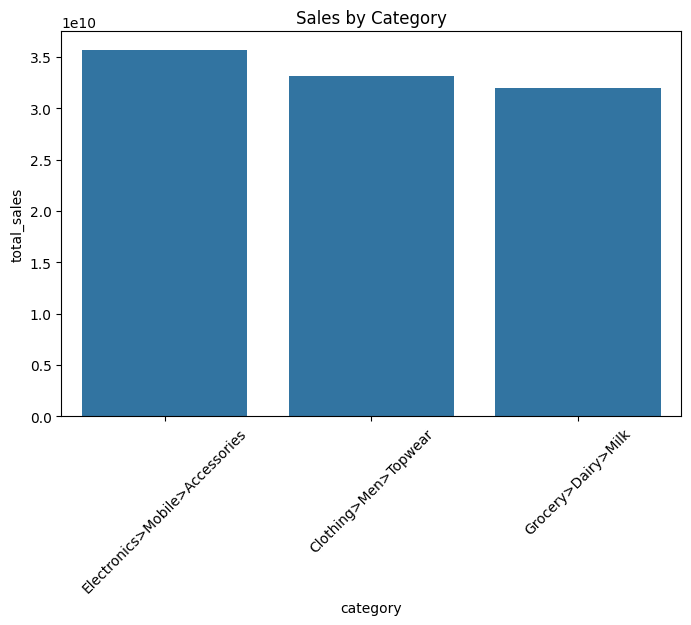

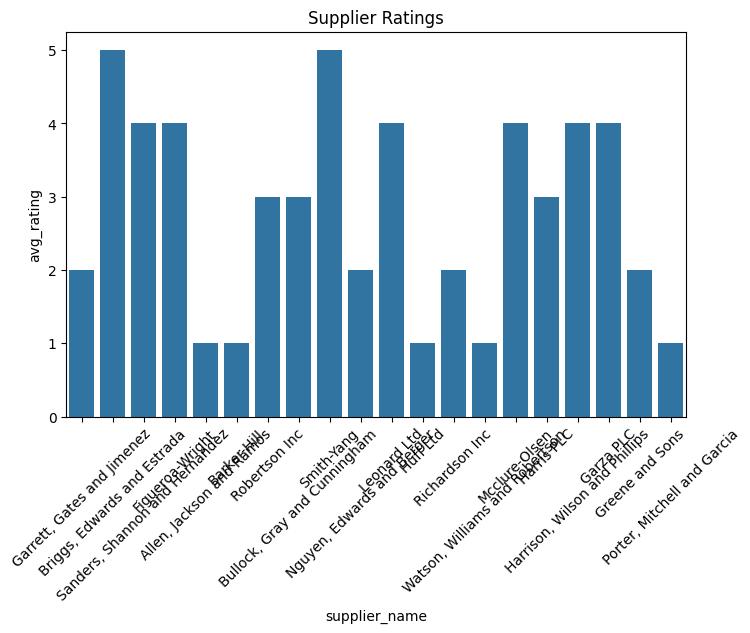

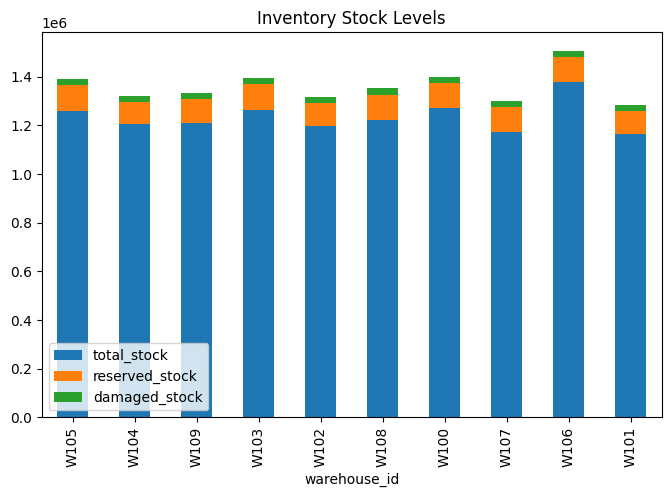

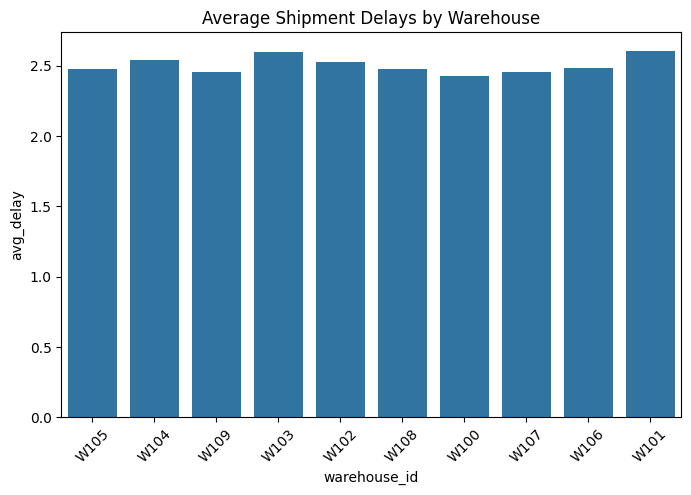

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sales by Category
sales_df = spark.read.parquet(f"{base_path}/gold/sales_by_category").toPandas()
plt.figure(figsize=(8,5))
sns.barplot(x="category", y="total_sales", data=sales_df)
plt.title("Sales by Category")
plt.xticks(rotation=45)
plt.show()

# Supplier Performance
suppliers_df = spark.read.parquet(f"{base_path}/gold/supplier_performance").toPandas()
plt.figure(figsize=(8,5))
sns.barplot(x="supplier_name", y="avg_rating", data=suppliers_df)
plt.title("Supplier Ratings")
plt.xticks(rotation=45)
plt.show()

# Inventory Stock Levels
inventory_df = spark.read.parquet(f"{base_path}/gold/inventory_stock_levels").toPandas()
inventory_df.plot(x="warehouse_id", kind="bar", stacked=True,
                  y=["total_stock","reserved_stock","damaged_stock"],
                  figsize=(8,5), title="Inventory Stock Levels")
plt.show()

# Shipment Delays
delays_df = spark.read.parquet(f"{base_path}/gold/shipment_delays").toPandas()
plt.figure(figsize=(8,5))
sns.barplot(x="warehouse_id", y="avg_delay", data=delays_df)
plt.title("Average Shipment Delays by Warehouse")
plt.xticks(rotation=45)
plt.show()


## Step 8: Export Gold Tables for Power BI


In [0]:
# Storage details
storage_account = "iaspstoragegen2"   # must match your blob URL
container = "iaspcontainer"

# Full SAS token string
sas_token = "sv=2026-02-06&ss=b&srt=co&sp=rwdlacyx&se=2026-08-15T15:45:06Z&st=2026-08-01T07:30:06Z&spr=https&sig=pWHGDx6p37OwjiKtULL9dVKaFwQKjJZj%2BRjhNLcfD8E%3D"

# ✅ Correct config: SAS only (no account key line!)
spark.conf.set(
    f"fs.azure.sas.{container}.{storage_account}.dfs.core.windows.net",
    sas_token
)

# Base path for all reads/writes
base_path = f"abfss://{container}@{storage_account}.dfs.core.windows.net"


In [0]:
df_test = spark.createDataFrame([(1,"ok"),(2,"test")], ["id","status"])
df_test.write.mode("overwrite").parquet(f"{base_path}/gold/test_df")


In [0]:
from pyspark.sql import functions as F

# Step 6: Create Silver Transactions from Bronze
bronze_df = spark.read.parquet(f"{base_path}/bronze/transactions")

silver_transactions = bronze_df.select(
    "transaction_id",
    "transaction_type",
    "transaction_timestamp",
    "product_id",
    "supplier_id",
    "warehouse_id",
    "quantity",
    "unit_price",
    "channel",
    "reference_id",
    "total_price"
).withColumn("quantity", F.col("quantity").cast("double")) \
 .withColumn("unit_price", F.col("unit_price").cast("double")) \
 .withColumn("total_amount", F.col("quantity") * F.col("unit_price")) \
 .withColumn("month", F.date_format("transaction_timestamp", "yyyy-MM"))


In [0]:
# Sales Summary
sales_summary = silver_transactions.groupBy("product_id").agg(
    F.sum("quantity").alias("total_units_sold"),
    F.sum("total_amount").alias("total_revenue")
)

# Inventory Snapshot
inventory_snapshot = silver_transactions.groupBy("product_id", "warehouse_id").agg(
    F.sum("quantity").alias("current_stock"),
    F.sum("total_amount").alias("inventory_value")
)

# Supplier Performance
supplier_performance = silver_transactions.groupBy("supplier_id").agg(
    F.count("transaction_id").alias("deliveries"),
    F.countDistinct("reference_id").alias("unique_references")
)

# Low Stock Alert
low_stock_alert = inventory_snapshot.filter(F.col("current_stock") < 10)

# Product Movement (removed stock_in/stock_out, replaced with quantity trend)
product_movement = silver_transactions.groupBy("product_id", "channel").agg(
    F.sum("quantity").alias("total_quantity"),
    F.sum("total_amount").alias("total_sales")
)

# Sales Trend
sales_trend = silver_transactions.groupBy("month").agg(
    F.sum("total_amount").alias("monthly_revenue")
)


In [0]:
sales_summary.write.mode("overwrite").parquet(f"{base_path}/gold/sales_summary")
inventory_snapshot.write.mode("overwrite").parquet(f"{base_path}/gold/inventory_snapshot")
supplier_performance.write.mode("overwrite").parquet(f"{base_path}/gold/supplier_performance")
low_stock_alert.write.mode("overwrite").parquet(f"{base_path}/gold/low_stock_alert")
product_movement.write.mode("overwrite").parquet(f"{base_path}/gold/product_movement")
sales_trend.write.mode("overwrite").parquet(f"{base_path}/gold/sales_trend")


In [0]:
dbutils.fs.ls(f"{base_path}/gold/")


[FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/gold/inventory_snapshot/', name='inventory_snapshot/', size=0, modificationTime=1785578514000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/gold/inventory_stock_levels/', name='inventory_stock_levels/', size=0, modificationTime=1785563566000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/gold/low_stock_alert/', name='low_stock_alert/', size=0, modificationTime=1785578518000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/gold/product_movement/', name='product_movement/', size=0, modificationTime=1785578519000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/gold/sales_by_category/', name='sales_by_category/', size=0, modificationTime=1785563151000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/gold/sales_summary/', name='sales_summary/', size=0, modificationTime=1785

In [0]:
dbutils.fs.ls(f"{base_path}/gold/sales_summary/")


[FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/gold/sales_summary/_SUCCESS', name='_SUCCESS', size=0, modificationTime=1785578513000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/gold/sales_summary/_committed_2320791686178328520', name='_committed_2320791686178328520', size=123, modificationTime=1785578513000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/gold/sales_summary/_started_2320791686178328520', name='_started_2320791686178328520', size=0, modificationTime=1785578513000),
 FileInfo(path='abfss://iaspcontainer@iaspstoragegen2.dfs.core.windows.net/gold/sales_summary/part-00000-tid-2320791686178328520-a329df40-6fa6-4385-9e64-6cc88e4fe740-22-1.c000.snappy.parquet', name='part-00000-tid-2320791686178328520-a329df40-6fa6-4385-9e64-6cc88e4fe740-22-1.c000.snappy.parquet', size=9142, modificationTime=1785578513000)]

In [0]:
df_check = spark.read.parquet(f"{base_path}/gold/sales_summary")
df_check.show(5)


+----------+----------------+--------------------+
|product_id|total_units_sold|       total_revenue|
+----------+----------------+--------------------+
|     P1329|          1937.0|5.1532134499999985E7|
|     P1311|          2030.0|       4.593014567E7|
|     P1060|          2835.0| 8.253557077000001E7|
|     P1023|          2013.0| 4.772305632000001E7|
|     P1217|          2275.0|       5.572581755E7|
+----------+----------------+--------------------+
only showing top 5 rows
